# Конструирование алгоритмов mclp

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime
from genesis.tools import timing
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import osmnx as ox

In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [3]:
class BestNodesGenesis(BestPointsBase):
    '''
    Поиск лучших узлов для размещения n объектов.
    '''

    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 best_point_function: BestPointsBase,
                 iterations=5,
                 **kwargs) -> None:
        
        self.best_point_function = best_point_function
        self.iterations = iterations
        super().__init__(state_function, metric_function, **kwargs)


    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: list|dict,
                 static_nodes: list|dict = None,
                 before_iters_start_function=None,
                 iter_calc_end_function=None,
                 area = None,
                 **kwargs):
        
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
        if not static_nodes is None:
            if not ((isinstance(dynamic_nodes,list) and isinstance(static_nodes,list)) or \
                (isinstance(dynamic_nodes,dict) and isinstance(static_nodes,dict))):
                raise TypeError("Аргументы `dynamic_nodes` и `static_nodes` должны быть одинакового типа: list|dict")


        # node_metric_func = NodeMetric(self.state_function, self.metric_function, self.appr_val, err_val=None)

        if static_nodes is None:
            if isinstance(dynamic_nodes,list):
                static_nodes = []
            elif isinstance(dynamic_nodes,dict):
                static_nodes = {}
        # print(dynamic_nodes, static_nodes)

        # 0. Получение списка (или словаря) узлов для расчета
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}

        # 1. Расчет состояния
        times, nearest = self.state_function(env=env, points=start_nodes, **kwargs)   # area=area, - убрал

        # 2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, area=area, **kwargs)
        best_dynamic_nodes = dynamic_nodes

        # выполняем функцию перед началом итераций
        if before_iters_start_function:
            before_iters_start_function(
                                    best_metric=best_metric,
                                    dynamic_nodes=dynamic_nodes,
                                    static_nodes=static_nodes
                                    )

        # best_metric = None
        # best_dynamic_nodes = dynamic_nodes
        for iteration in range(self.iterations):
            # # 0. Приведение к единому типу переменной
            # if isinstance(dynamic_nodes,list):
            #     start_nodes = dynamic_nodes+static_nodes
            # elif isinstance(dynamic_nodes,dict):
            #     start_nodes = {**dynamic_nodes, **static_nodes}

            # # 1. Расчет состояния
            # times, nearest = self.state_function(env=env, points=start_nodes, area=area, **kwargs)



            # 2. Поиск для каждого из dinamic_nodes наилучшего размещения в пределах своей зоны обслуживания
            # 2.1. Для списка:
            if isinstance(dynamic_nodes, list):
                new_dynamic_nodes = []
                for dynamic_node in dynamic_nodes:
                    # print(dynamic_node)
                    # Определяем список узлов в которые из узла dynamic_node можно прибыть первым
                    # node_area_nodes = [n for n in nearest if n==dynamic_node]
                    node_area_nodes = [k for k,v in nearest.items() if v==dynamic_node]
                    # Определяем подграф зоны обслуживания для узла dynamic_node
                    node_area_G = nx.subgraph(env, node_area_nodes)
                    # print(dynamic_node, node_area_nodes)
                    print(dynamic_node in node_area_nodes)
                    # Определяем лучший узел
                    best_nodes, _ = self.best_point_function(env=node_area_G, 
                                                                    start_node=dynamic_node,
                                                                    area=area,
                                                                    **kwargs)[:2] # [:2] Это для ограничения вывода дебаг-данных в некоторых функциях
                    if isinstance(best_nodes, list):
                        best_nodes = best_nodes[0]
                    # Добавляем полученный узел в новый список
                    new_dynamic_nodes.append(best_nodes)
            else:
                new_dynamic_nodes = {}
                for dynamic_node_id, dynamic_node_key in dynamic_nodes.items():
                    # print(dynamic_node)
                    # Определяем список узлов в которые из узла dynamic_node можно прибыть первым
                    # node_area_nodes = [n for n in nearest if n==dynamic_node]
                    node_area_nodes = [k for k,v in nearest.items() if v==dynamic_node_key]
                    # Определяем подграф зоны обслуживания для узла dynamic_node
                    node_area_G = nx.subgraph(env, node_area_nodes)
                    # Определяем лучший узел
                    best_nodes, _ = self.best_point_function(env=node_area_G, 
                                                                    start_node=dynamic_node_id,
                                                                    area=area,
                                                                    **kwargs)[:2] # [:2] Это для ограничения вывода дебаг-данных в некоторых функциях
                    if isinstance(best_nodes, list):
                        best_nodes = best_nodes[0]
                    # Добавляем полученный узел в новый список
                    new_dynamic_nodes[best_nodes] = dynamic_node_key



            # Заменяем список dynamic_nodes списком с новыми, лучшими узлами
            dynamic_nodes = new_dynamic_nodes

            # 0. Приведение к единому типу переменной
            if isinstance(dynamic_nodes,list):
                start_nodes = dynamic_nodes+static_nodes
            elif isinstance(dynamic_nodes,dict):
                start_nodes = {**dynamic_nodes, **static_nodes}

            # 1. Расчет состояния
            times, nearest = self.state_function(env=env, points=start_nodes, **kwargs)   # area=area, 

            # 3. Расчет метрики состояния
            state_metric = self.metric_function(times, area=area, **kwargs)
            if best_metric is None:
                best_metric = state_metric

            # 4. Оценка метрики состояния
            print(best_metric, state_metric)
            if self.metric_function.compare(best_metric, state_metric) == state_metric:
                best_metric = state_metric
                best_dynamic_nodes = dynamic_nodes

            # выполняем функцию завершения расчета для итерации
            if iter_calc_end_function:
                iter_calc_end_function(i=iteration,
                                       best_metric=best_metric,
                                       dynamic_nodes=best_dynamic_nodes,
                                       static_nodes=static_nodes)


        return best_dynamic_nodes, best_metric


cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])

def iter_end_func(**kwds):
    # print('Итерация:', kwds['i'])
    print(kwds)
    # dynamic_nodes = kwds['dynamic_nodes']
    # try:
    #     static_nodes = kwds['static_nodes']
    # except:
    #     static_nodes = None
    # if not static_nodes is None:
    #     if isinstance(dynamic_nodes,list):
    #         start_nodes = dynamic_nodes+static_nodes
    #     elif isinstance(dynamic_nodes,dict):
    #         start_nodes = {**dynamic_nodes, **static_nodes}
    # times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)

    # nx.set_node_attributes(G, nearest, 'nearest')
    # nx.set_node_attributes(G, times, 'route_time')

    # nds = ox.graph_to_gdfs(G, edges=False)
    # fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    # ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    # nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
    # nds.loc[dynamic_nodes.keys()].plot(ax=ax1, markersize=25, color='red')
    # if static_nodes:
    #     nds.loc[static_nodes.keys()].plot(ax=ax1, markersize=25, color='k')

    # ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    # nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
    # nds.loc[dynamic_nodes.keys()].plot(ax=ax2, markersize=25, color='red')
    # if static_nodes:
    #     nds.loc[static_nodes.keys()].plot(ax=ax2, markersize=25, color='k')

    # plt.show()





# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)


nodes = list(G.nodes())
# existed_units = {nodes[100]:'A', 
#                 nodes[2000]:'B', 
#                 }
# new_units = {nodes[3000]:'c',
#              nodes[4000]:'d'}
new_units = {nodes[100]:'A', 
            nodes[2000]:'B',
            nodes[3000]:'c',
            nodes[4000]:'d'}
# existed_units = list(existed_units.keys())
new_units = list(new_units.keys())
# print(existed_units)

# iter_end_func(dynamic_nodes=new_units, static_nodes={})


BNF = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime())
def BNF(env, start_node, area=None):
    bnch_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max))
    bnch_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())

    best_node, best_metric = bnch_max(env=env, start_node=start_node, area=area)
    best_node, best_metric = bnch_mean(env=env, start_node=best_node, area=area)
    return best_node, best_metric

BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF,
                    #    best_point_function=BestNodeHillClimbingMaxMean,
                       iterations=5,
                       ))

# BNG(env=G, dynamic_nodes=new_units, static_nodes=existed_units, iter_calc_end_function=iter_end_func, area=points_mask)
# BNG(env=G, dynamic_nodes=new_units, static_nodes=existed_units, iter_calc_end_function=iter_end_func)
BNG(env=G,
    dynamic_nodes=new_units,
    # static_nodes=existed_units,
    before_iters_start_function=iter_end_func,
    iter_calc_end_function=iter_end_func,
    area=points_mask,
    )
# BNG(env=G, dynamic_nodes=new_units, iter_calc_end_function=iter_end_func, area=points_mask)

{'best_metric': 5.2880732710581775, 'dynamic_nodes': [1296599762, 2042076750, 2760591335, 4901942432], 'static_nodes': []}
1296599762 [1296599762, 2366929606, 1577756011, 2106897129, 1296599763, 1644098164, 2106897127, 1577738840, 1296599764, 5678829120, 1577738846, 1676510290, 1296599765, 1577756013, 1577738848, 2366929614, 9086101175, 9086101187, 1495241218, 9086101188, 9086101186, 5678829119, 3114758155, 1577756015, 9086101174, 9086101173, 1296599766, 1577756021, 3114758150, 1577726929, 5116711724, 9086101185, 9086101172, 1577726928, 1577756019, 5116709214, 1296599779, 3114758151, 2546773068, 5116709187, 5116709192, 5116711737, 1577726927, 9085465235, 3114758148, 5678829117, 5116711744, 9086101171, 1296599778, 9085465234, 9085465233, 5116711736, 1676510280, 5116709208, 2972892414, 3181236948, 1676510319, 5116709189, 5116711739, 5116709195, 5116709209, 7592501563, 5116711723, 5116709200, 5116709211, 3114758149, 1577756017, 9086101189, 1705509853, 1296599772, 5116711738, 9086101170, 5

ValueError: Указанный стартовый узел неприемлем, в связи с его слабой связностью с остальной частью графа

{'best_metric': 7.262001771503841, 'dynamic_nodes': {4901942432: 'c', 2042076750: 'd'}, 'static_nodes': {2760591335: 'A', 1296599762: 'B'}}


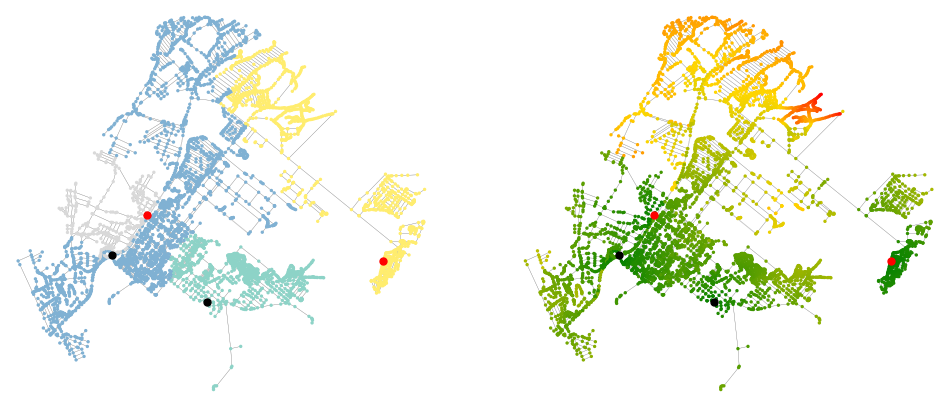

7.262001771503841 5.770172498222072
{'i': 0, 'best_metric': 5.770172498222072, 'dynamic_nodes': {2712076292: 'c', 2034401575: 'd'}, 'static_nodes': {2760591335: 'A', 1296599762: 'B'}}


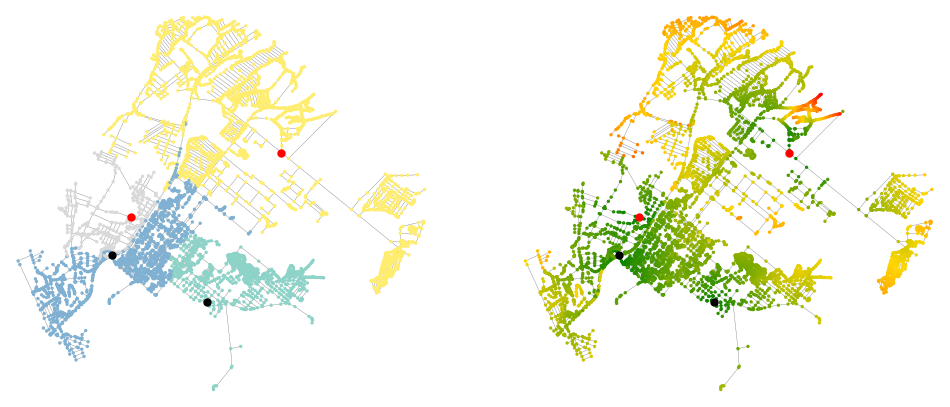

5.770172498222072 5.44703107074076
{'i': 1, 'best_metric': 5.44703107074076, 'dynamic_nodes': {2712076292: 'c', 2034401724: 'd'}, 'static_nodes': {2760591335: 'A', 1296599762: 'B'}}


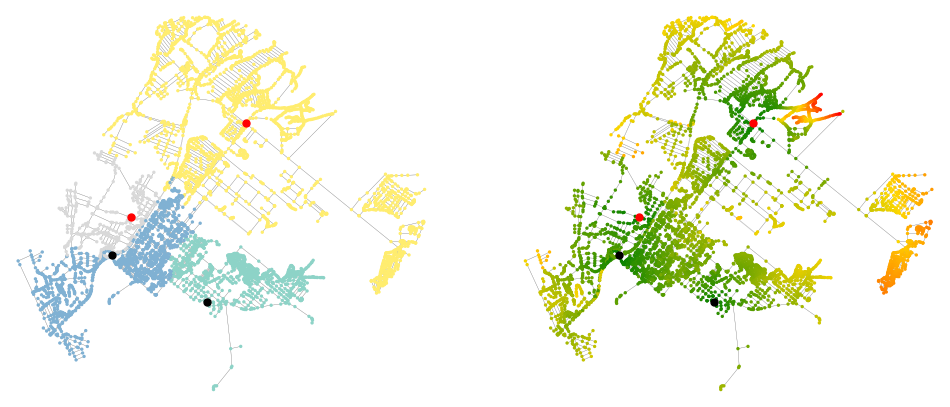

5.44703107074076 5.446871377738268
{'i': 2, 'best_metric': 5.446871377738268, 'dynamic_nodes': {2712076292: 'c', 2034401723: 'd'}, 'static_nodes': {2760591335: 'A', 1296599762: 'B'}}


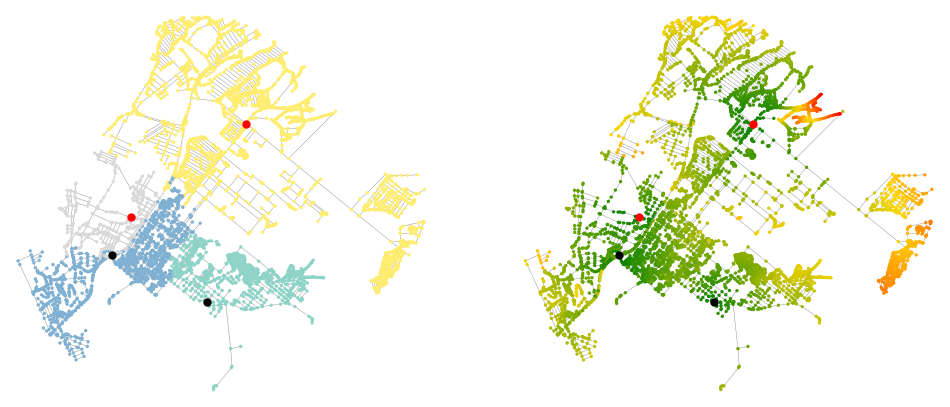

5.446871377738268 5.446871377738268
{'i': 3, 'best_metric': 5.446871377738268, 'dynamic_nodes': {2712076292: 'c', 2034401723: 'd'}, 'static_nodes': {2760591335: 'A', 1296599762: 'B'}}


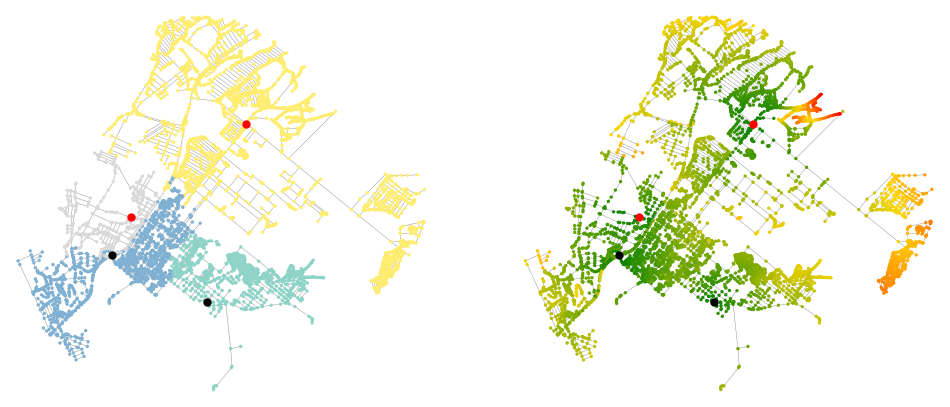

5.446871377738268 5.446871377738268
{'i': 4, 'best_metric': 5.446871377738268, 'dynamic_nodes': {2712076292: 'c', 2034401723: 'd'}, 'static_nodes': {2760591335: 'A', 1296599762: 'B'}}


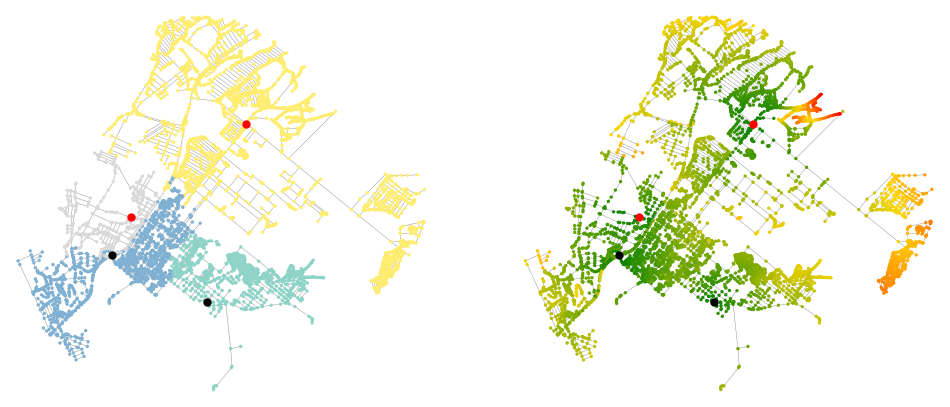

ВРЕМЯ: 79.39 сек


({2712076292: 'c', 2034401723: 'd'}, 5.446871377738268)

In [16]:
existed_units = {nodes[3000]:'A', 
                nodes[100]:'B', 
                }
new_units = {nodes[4000]:'c',
             nodes[2000]:'d'}


# BNF = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
#                        metric_function=ArrivalTime())
def BNF(env, start_node, area=None):
    bnch_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max))
    bnch_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())

    best_node, best_metric = bnch_max(env=env, start_node=start_node, area=area)
    best_node, best_metric = bnch_mean(env=env, start_node=best_node, area=area)
    return best_node, best_metric

BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF,
                       iterations=5,
                       ))

BNG(env=G,
    dynamic_nodes=new_units,
    static_nodes=existed_units,
    before_iters_start_function=iter_end_func,
    iter_calc_end_function=iter_end_func,
    # area=points_mask,
    )

{'best_metric': 5.2880732710581775, 'dynamic_nodes': {4901942432: 'c', 2042076750: 'd'}, 'static_nodes': {2760591335: 'A', 1296599762: 'B'}}


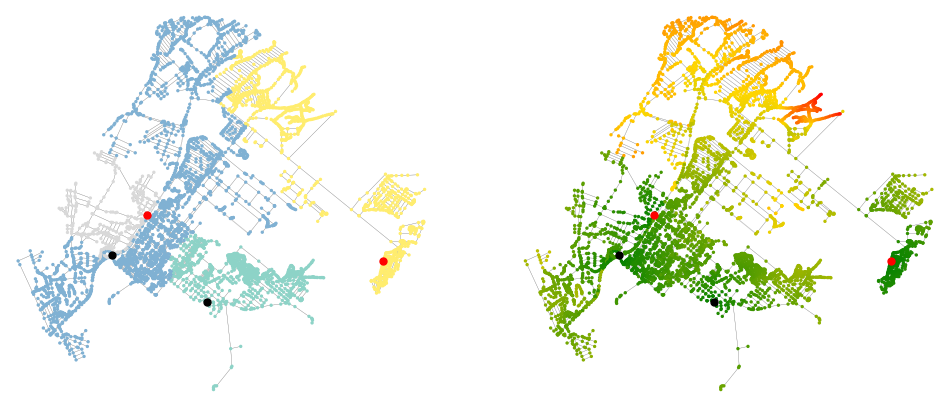

NodeNotFound: Node 4901942432 not found in graph

In [17]:
existed_units = {nodes[3000]:'A', 
                nodes[100]:'B', 
                }
new_units = {nodes[4000]:'c',
             nodes[2000]:'d'}


# BNF = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
#                        metric_function=ArrivalTime())
def BNF(env, start_node, area=None):
    bnch_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max))
    bnch_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())

    best_node, best_metric = bnch_max(env=env, start_node=start_node, area=area)
    best_node, best_metric = bnch_mean(env=env, start_node=best_node, area=area)
    return best_node, best_metric

BNG = timing(BestNodesGenesis(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF,
                       iterations=5,
                       ))


BNG(env=G,
    dynamic_nodes=new_units,
    static_nodes=existed_units,
    before_iters_start_function=iter_end_func,
    iter_calc_end_function=iter_end_func,
    area=points_mask,
    )